<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/03_deep_learning/neural_network_basics/experiment_ann_multiclass_classification_iris_basic_and_advanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense

from tensorflow.keras.utils import to_categorical

In [2]:
iris = load_iris()

X = iris.data

y = iris.target

One-Hot Encode Labels

For multi-class classification.

In [3]:
y = to_categorical(y)

print(y[:5])

[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Feature Scaling

In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Build ANN Model

Initialize Network

In [6]:
model = Sequential()

Input + Hidden Layer 1

Using ReLU activation.

$$f(x)=max(0,x)$$

In [7]:
model.add(
    Dense(
        16,
        activation="relu",
        input_shape=(4,)
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Hidden Layer 2

In [8]:
model.add(
    Dense(
        8,
        activation="relu"
    )
)

Output Layer

Using Softmax.

$$\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j} e^{z_j}}$$


In [9]:
model.add(
    Dense(
        3,
        activation="softmax"
    )
)

Compile Model

Using:

*   Adam optimizer
*   Categorical Crossentropy loss






In [10]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

Model Summary

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

Train ANN

In [12]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=8,
    validation_split=0.2
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.1979 - loss: 1.1622 - val_accuracy: 0.2083 - val_loss: 1.1753
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2604 - loss: 1.1147 - val_accuracy: 0.3750 - val_loss: 1.1247
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3542 - loss: 1.0793 - val_accuracy: 0.5000 - val_loss: 1.0814
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5000 - loss: 1.0467 - val_accuracy: 0.6250 - val_loss: 1.0421
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5312 - loss: 1.0188 - val_accuracy: 0.6250 - val_loss: 1.0112
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5312 - loss: 0.9929 - val_accuracy: 0.6250 - val_loss: 0.9808
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5521 - loss: 0.9706 - val_accuracy: 0.6667 - val_loss: 0.9456
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5312 - loss: 0.9470 - val_accuracy: 0.6

Evaluate Model

In [13]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 1.0000 - loss: 0.0519
Test Accuracy: 1.0


Make Predictions

In [14]:
predictions = model.predict(X_test)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

print(predicted_classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


Actual Classes

In [15]:
actual_classes = np.argmax(
    y_test,
    axis=1
)

print(actual_classes)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


Predict New Flower

In [16]:
new_sample = np.array([
    [5.1, 3.5, 1.4, 0.2]
])

new_sample = scaler.transform(new_sample)

prediction = model.predict(new_sample)

predicted_class = np.argmax(prediction)

print("Predicted Class:",
      predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Predicted Class: 0


Save ANN Model

In [18]:
model.save("iris_ann_model.h5")

# **ADVANCED ANN**

Import Libraries

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.utils import to_categorical

Load Dataset

In [20]:
iris = load_iris()

X = iris.data

y = iris.target

One-Hot Encoding

In [21]:
y = to_categorical(y)

Train-Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Feature Scaling

In [23]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Build Advanced ANN

In [24]:
model = Sequential()

# ====================================================
# Hidden Layer 1
# ====================================================

model.add(
    Dense(
        128,
        activation="relu",
        input_shape=(4,)
    )
)

model.add(BatchNormalization())

model.add(Dropout(0.3))

# ====================================================
# Hidden Layer 2
# ====================================================

model.add(
    Dense(
        64,
        activation="relu"
    )
)

model.add(BatchNormalization())

model.add(Dropout(0.3))

# ====================================================
# Hidden Layer 3
# ====================================================

model.add(
    Dense(
        32,
        activation="relu"
    )
)

# ====================================================
# Output Layer
# ====================================================

model.add(
    Dense(
        3,
        activation="softmax"
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile Model

In [25]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

Model Summary

In [26]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,843 (46.26 KB)

 Trainable params: 11,459 (44.76 KB)

 Non-trainable params: 384 (1.50 KB)

Early Stopping

Stops training automatically when validation stops improving.

In [27]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

Train Model

In [28]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 141ms/step - accuracy: 0.3542 - loss: 1.4531 - val_accuracy: 0.5000 - val_loss: 1.0425
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6354 - loss: 0.7621 - val_accuracy: 0.7917 - val_loss: 0.9577
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7708 - loss: 0.6058 - val_accuracy: 0.7917 - val_loss: 0.8895
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8750 - loss: 0.4340 - val_accuracy: 0.8333 - val_loss: 0.8456
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8542 - loss: 0.4504 - val_accuracy: 0.8333 - val_loss: 0.8056
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9062 - loss: 0.2799 - val_accuracy: 0.8750 - val_loss: 0.7716
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9375 - loss: 0.2418 - val_accuracy: 0.8750 - val_loss: 0.7357
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9062 - loss: 0.2723 - val_accuracy: 0.9167 - val_loss

Evaluate Model

In [29]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9667 - loss: 0.0368
Test Accuracy: 0.9666666388511658


Predictions

In [30]:
predictions = model.predict(X_test)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

actual_classes = np.argmax(
    y_test,
    axis=1
)

print(predicted_classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
[1 0 2 1 1 0 1 2 2 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


Classification Report

In [31]:
print(
    classification_report(
        actual_classes,
        predicted_classes
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



Confusion Matrix

In [32]:
cm = confusion_matrix(
    actual_classes,
    predicted_classes
)

print(cm)

[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]


Plot Training Curves

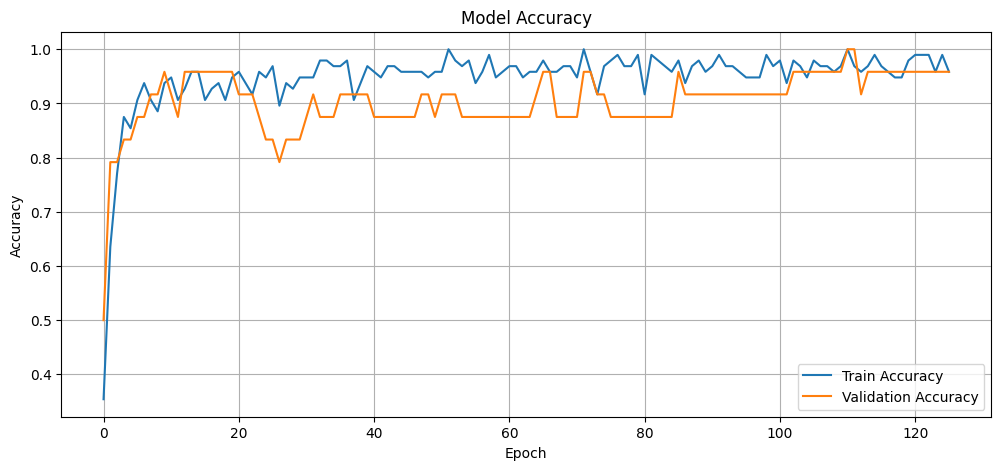

In [33]:
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.plot(
    history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

Plot Loss Curves

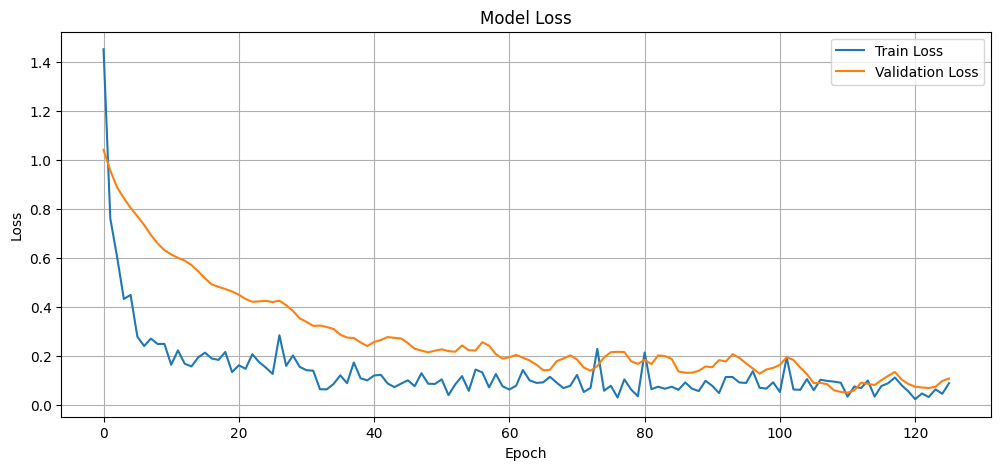

In [34]:
plt.figure(figsize=(12, 5))

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

Predict New Sample

In [35]:
new_sample = np.array([
    [5.1, 3.5, 1.4, 0.2]
])

new_sample = scaler.transform(new_sample)

prediction = model.predict(new_sample)

predicted_class = np.argmax(prediction)

print("Predicted Class:",
      predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
Predicted Class: 0


Save Model

In [36]:
model.save("advanced_iris_ann.keras")

* **Hidden Layer:** $A^{[l]} = \text{ReLU}(W^{[l]}A^{[l-1]} + b^{[l]})$
* **Batch Normalization:** $\hat{x} = \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}}$
* **Dropout:** $A^{[l]} = A^{[l]} * D^{[l]}$
* **Softmax Output:** $\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j} e^{z_j}}$
* **Cross Entropy Loss:** $L = -\sum y_i \log(\hat{y}_i)$
